https://www.researchgate.net/profile/Satyam-Chauhan-3/publication/392512342_Quantitative_AI_Models_for_Company_Valuations/links/6845e424df0e3f544f5da4a4/Quantitative-AI-Models-for-Company-Valuations.pdf

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

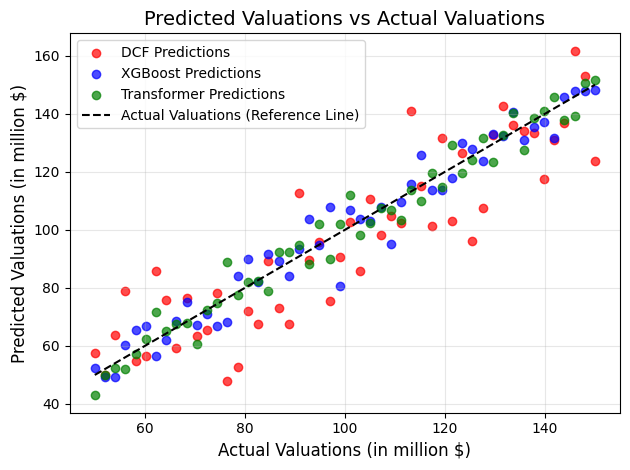

In [ ]:
np.random.seed(42)

# Generate sample data for actual and predicted valuations np.random.seed(42)
actual_valuations = np.linspace(50, 150, 50) # Actual market valuations
dcf_predictions = actual_valuations + np.random.normal(0, 15, 50) # DCF predictions with noise
xgboost_predictions = actual_valuations + np.random.normal(0, 7,50) # XGBoost predictions with lower noise
transformer_predictions = actual_valuations + np.random. normal(0, 5, 50) # Transformer predictions with lowest noise
# Plotting the scatter plots plt.figure(figsize=(10, 6))
# Scatter plots for each model
plt.scatter(actual_valuations,
dcf_predictions, color='red',
label='DCF Predictions', alpha=0.7)
plt.scatter(actual_valuations, xgboost_predictions, color='blue', label='XGBoost Predictions', alpha=0.7)
plt.scatter(actual_valuations,
transformer_predictions,
color='green', label='Transformer Predictions', alpha=0.7)
# Plot actual valuations line
plt.plot(actual_valuations, actual_valuations, color='black', linestyle='--', label='Actual Valuations (Reference Line)')
#Labels, legend and title
plt.title('Predicted Valuations vs Actual Valuations', fontsize=14)
plt.xlabel('Actual Valuations (in million $)', fontsize=12)
plt.ylabel('Predicted Valuations (in million $)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


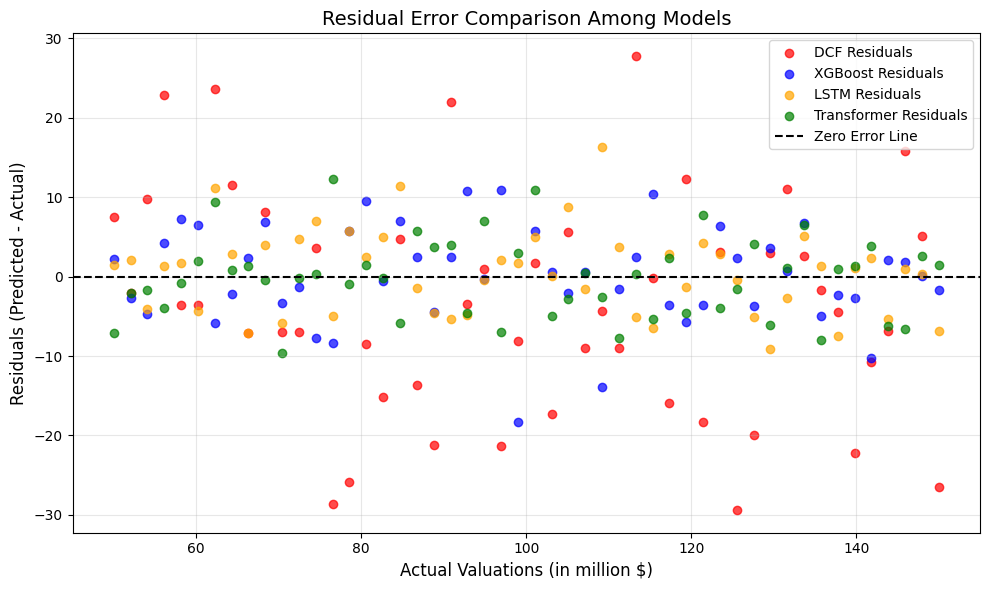

In [ ]:
# Calculate residuals (errors) for each model
dcf_residuals = dcf_predictions - actual_valuations
xgboost_residuals = xgboost_predictions - actual_valuations
transformer_residuals = transformer_predictions - actual_valuations
# Generate sample data for LSTM predictions and residuals
lstm_predictions = actual_valuations + np.random.normal(0, 6, 50) # LSTM predictions with moderate noise
lstm_residuals = lstm_predictions - actual_valuations
# Plotting residual errors for each model
plt.figure(figsize=(10,6))
# Residuals for each model
plt.scatter(actual_valuations,
dcf_residuals, color='red',
label='DCF Residuals', alpha=0.7)
plt.scatter(actual_valuations, xgboost_residuals, color='blue', label='XGBoost Residuals', alpha=0.7)
plt.scatter(actual_valuations, lstm_residuals, color='orange',
label='LSTM Residuals', alpha=0.7)
plt.scatter(actual_valuations,
transformer_residuals,
color='green', label='Transformer Residuals', alpha=0.7)
# Zero error reference line
plt.axhline(y=0, color='black', linestyle='--', label='Zero Error Line')
# Labels, legend and title
plt.title('Residual Error Comparison Among Models', fontsize=14)
plt.xlabel('Actual Valuations (in million $)', fontsize=12)
plt.ylabel('Residuals (Predicted - Actual)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
dat.calendar

NameError: name 'dat' is not defined

In [ ]:
dat.analyst_price_targets

{'current': 495.0,
 'high': 700.0,
 'low': 483.0,
 'mean': 613.8916,
 'median': 630.0}

## DCF COMMENCE A PARTIR DE LA

In [ ]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import datetime
import time
!pip install yahooquery
from yahooquery import Ticker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 2.0 MB/s eta 0:00:00


In [ ]:
stock = Ticker("AAPL")

In [ ]:
df_cash = pd.DataFrame(stock.cash_flow())
df_cash['asOfDate'] = pd.to_datetime(df_cash['asOfDate'])
df_cash.set_index('asOfDate', inplace=True)
cash_period = df_cash['periodType'].iloc[0]
df_cash = df_cash.iloc[:,2:]
# Supprimer les NaN de toute la colonne au niveau du DataFrame
df_cash = df_cash.dropna(subset=['FreeCashFlow'])

# Puis afficher la colonne
df_cash['FreeCashFlow']


,FreeCashFlow
asOfDate,
2021-09-30,9.295300e+10
2022-09-30,1.114430e+11
2023-09-30,9.958400e+10
2024-09-30,1.088070e+11
2025-06-30,9.618400e+10


In [ ]:
import pandas as pd
import datetime as dt

# Exemple : récupérer les cash flows
df_cash = pd.DataFrame(stock.cash_flow())
df_cash['asOfDate'] = pd.to_datetime(df_cash['asOfDate'])
df_cash.set_index('asOfDate', inplace=True)

# On garde uniquement FreeCashFlow
if "FreeCashFlow" not in df_cash.columns:
    raise ValueError("FreeCashFlow non trouvé dans les données.")

fcf_series = df_cash["FreeCashFlow"].dropna().sort_index()

# Vérifier la différence entre les 2 dernières dates
if len(fcf_series) >= 2:
    date_1 = fcf_series.index[-1]
    date_2 = fcf_series.index[-2]
    diff_days = (date_1 - date_2).days

    # Si l'écart n'est pas ~1 an, ajuster le FCF
    if diff_days not in (365, 366):
        print(f"⚠️ Attention : écart de {diff_days} jours entre {date_2.date()} et {date_1.date()}")

        # Ajustement proportionnel du dernier FCF
        fcf_adjusted = fcf_series.iloc[-1] * (365 / diff_days)

        # Remplacer la dernière valeur par l'ajustée
        fcf_series.iloc[-1] = fcf_adjusted
        print(f"✅ FCF ajusté : {fcf_adjusted}")


⚠️ Attention : écart de 273 jours entre 2024-09-30 et 2025-06-30
✅ FCF ajusté : 128597655677.65567


In [ ]:
##
fcf_series

,FreeCashFlow
asOfDate,
2021-09-30,9.295300e+10
2022-09-30,1.114430e+11
2023-09-30,9.958400e+10
2024-09-30,1.088070e+11
2025-06-30,1.285977e+11


In [ ]:
df_balance = pd.DataFrame(stock.balance_sheet())
df_balance['asOfDate'] = pd.to_datetime(df_balance['asOfDate'])
df_balance.set_index('asOfDate', inplace=True)

df_balance = df_balance.iloc[:,2:]
df_balance

,AccountsPayable,AccountsReceivable,AccumulatedDepreciation,AvailableForSaleSecurities,CapitalLeaseObligations,CapitalStock,CashAndCashEquivalents,CashCashEquivalentsAndShortTermInvestments,CashEquivalents,CashFinancial,...,TotalCapitalization,TotalDebt,TotalEquityGrossMinorityInterest,TotalLiabilitiesNetMinorityInterest,TotalNonCurrentAssets,TotalNonCurrentLiabilitiesNetMinorityInterest,TotalTaxPayable,TradeandOtherPayablesNonCurrent,TreasurySharesNumber,WorkingCapital
asOfDate,,,,,,,,,,,,,,,,,,,,,
2020-09-30,NaN,NaN,NaN,NaN,9.842000e+09,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-09-30,5.476300e+10,2.627800e+10,-7.028300e+10,1.278770e+11,1.180300e+10,5.736500e+10,3.494000e+10,6.263900e+10,1.763500e+10,1.730500e+10,...,1.721960e+11,1.365220e+11,6.309000e+10,2.879120e+11,2.161660e+11,1.624310e+11,NaN,2.468900e+10,NaN,9.355000e+09
2022-09-30,6.411500e+10,2.818400e+10,-7.234000e+10,1.208050e+11,1.241100e+10,6.484900e+10,2.364600e+10,4.830400e+10,5.100000e+09,1.854600e+10,...,1.496310e+11,1.324800e+11,5.067200e+10,3.020830e+11,2.173500e+11,1.481010e+11,6.552000e+09,1.665700e+10,NaN,-1.857700e+10
2023-09-30,6.261100e+10,2.950800e+10,-7.088400e+10,1.005440e+11,1.284200e+10,7.381200e+10,2.996500e+10,6.155500e+10,1.606000e+09,2.835900e+10,...,1.574270e+11,1.110880e+11,6.214600e+10,2.904370e+11,2.090170e+11,1.451290e+11,8.819000e+09,1.545700e+10,0.0,-1.742000e+09
2024-09-30,6.896000e+10,3.341000e+10,-7.344800e+10,9.147900e+10,NaN,8.327600e+10,2.994300e+10,6.517100e+10,2.744000e+09,2.719900e+10,...,1.427000e+11,1.066290e+11,5.695000e+10,3.080300e+11,2.119930e+11,1.316380e+11,2.660100e+10,9.254000e+09,NaN,-2.340500e+10


In [ ]:
net_debt = df_balance['NetDebt'].iloc[-1]
net_debt

np.float64(76686000000.0)

In [ ]:
def column_to_list(df, column_name):
    data_list = df[column_name].tolist()
    # Removed the line that filtered out NaN values
    return data_list

In [ ]:
historic_fcf = column_to_list(df_cash, 'FreeCashFlow')
historic_fcf

[nan,
 92953000000.0,
 111443000000.0,
 99584000000.0,
 108807000000.0,
 96184000000.0]

In [ ]:
##
historic_fcf = fcf_series

In [ ]:
# A revoir
import numpy as np

# Calcul de la moyenne de croissance annuelle
fcf_avg_growth_rate = np.mean([(historic_fcf[i]-historic_fcf[i-1])/historic_fcf[i-1] for i in range(1, len(historic_fcf))])
fcf_avg_growth_rate

/tmp/ipython-input-3023648226.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fcf_avg_growth_rate = np.mean([(historic_fcf[i]-historic_fcf[i-1])/historic_fcf[i-1] for i in range(1, len(historic_fcf))])


np.float64(0.09175189367735345)

In [ ]:
future_year = 5

future_fcf = [historic_fcf[-1]*(1+fcf_avg_growth_rate)**(i+1) for i in range(future_year)]

future_fcf

/tmp/ipython-input-31677152.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  future_fcf = [historic_fcf[-1]*(1+fcf_avg_growth_rate)**(i+1) for i in range(future_year)]


[np.float64(140396734108.54883),
 np.float64(153278400329.12405),
 np.float64(167341983819.15665),
 np.float64(182695927726.2893),
 np.float64(199458625062.31723)]

/tmp/ipython-input-3229653023.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_index = pd.date_range(


Shape of future_index: (5,)
Shape of future_fcf: (5,)
Shape of historic_index_cleaned_np: (5,)
Shape of historic_fcf_cleaned_np: (5,)


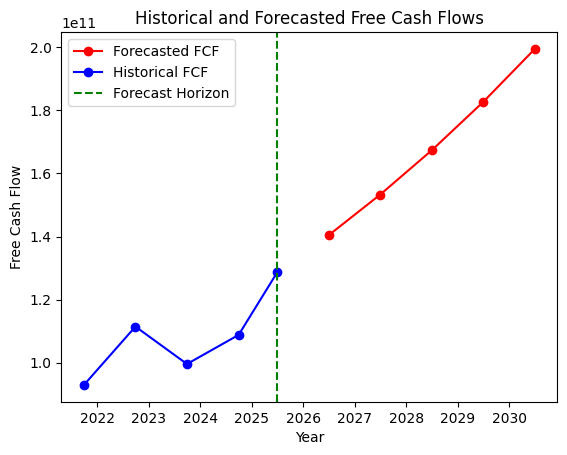

In [ ]:
# Forecast index
future_index = pd.date_range(
    start=df_cash.index[-1],
    periods=future_year + 1,
    freq=cash_period
)[1:]

# Nettoyage FCF historique
historic_fcf_cleaned = historic_fcf.dropna()
historic_index_cleaned = historic_fcf_cleaned.index

# Conversion en NumPy
historic_fcf_cleaned_np = historic_fcf_cleaned.values
historic_index_cleaned_np = historic_index_cleaned.values

print(f"Shape of future_index: {future_index.shape}")
print(f"Shape of future_fcf: {np.array(future_fcf).shape}")
print(f"Shape of historic_index_cleaned_np: {historic_index_cleaned_np.shape}")
print(f"Shape of historic_fcf_cleaned_np: {historic_fcf_cleaned_np.shape}")

# Plot
plt.plot(future_index, future_fcf, label='Forecasted FCF', color='r', marker='o')
plt.plot(historic_index_cleaned_np, historic_fcf_cleaned_np, label='Historical FCF', color='b', marker='o')
plt.title('Historical and Forecasted Free Cash Flows')
plt.xlabel('Year')
plt.ylabel('Free Cash Flow')
plt.axvline(x=df_cash.index[-1], color='g', linestyle='--', label='Forecast Horizon')
plt.legend()
plt.show()


In [ ]:
import yfinance as yf

# Exemple avec Apple
ticker = yf.Ticker("AAPL")

# Récupération du nombre d'actions en circulation
shares_outstanding = ticker.info.get("sharesOutstanding")

print("Nombre d'actions en circulation :", shares_outstanding)


Nombre d'actions en circulation : 14840399872


##WACC

$W = (\frac{E}{E+D}\times Re) + (\frac{D}{E+D}\times Rd \times (1-Tc))$

$E = Market \space cap$

$Re = R_f + \beta \times (E(R_m) – R_f )$

In [ ]:
def calculate_cost_of_equity(ticker, years=20):
    import datetime as dt
    import yfinance as yf
    import numpy as np

    # Dates
    today_dt = dt.datetime.today()
    delay = today_dt - dt.timedelta(days=365*years)

    # Télécharger le S&P500 (^GSPC)
    data = yf.download('^GSPC', start=delay, end=today_dt)

    # Rendement annualisé géométrique (CAGR)
    rm = (data["Close"].iloc[-1] / data["Close"].iloc[0]) ** (1/years) - 1

    # Taux sans risque (US 10 ans)
    tnx = yf.Ticker("^TNX")
    risk_free_rate = float(tnx.history(period="1d")["Close"].iloc[-1]) / 100  # en %

    # Prime de risque du marché
    market_risk_premium = float(rm - risk_free_rate)

    # Beta du titre
    beta = ticker.info.get("beta", np.nan)
    if np.isnan(beta):
        return np.nan

    return float(risk_free_rate + beta * market_risk_premium)



def calculate_wacc(ticker_symbol):
    ticker = yf.Ticker(ticker_symbol)

    # Valeur de marché des fonds propres (E)
    market_cap = ticker.info.get("marketCap", np.nan)

    # Bilan (pour la dette)
    balance_sheet = ticker.balance_sheet
    if isinstance(balance_sheet.columns, pd.MultiIndex):
        balance_sheet.columns = ["_".join(col).strip() for col in balance_sheet.columns.values]

    # Dette court terme + long terme
    short_term_debt = balance_sheet.loc["Short Long Term Debt"].iloc[0] if "Short Long Term Debt" in balance_sheet.index else 0
    long_term_debt = balance_sheet.loc["Long Term Debt"].iloc[0] if "Long Term Debt" in balance_sheet.index else 0
    total_debt = short_term_debt + long_term_debt

    # Compte de résultat (pour les intérêts et impôts)
    income_statement = ticker.income_stmt
    if isinstance(income_statement.columns, pd.MultiIndex):
        income_statement.columns = ["_".join(col).strip() for col in income_statement.columns.values]

    # Intérêts payés
    if "Interest Expense" in income_statement.index:
        interest_expenses = income_statement.loc["Interest Expense"].astype(float)
        avg_interest_expense = np.nanmean(interest_expenses)
    else:
        avg_interest_expense = np.nan

    # Taux effectif d’impôt
    if "Tax Rate For Calcs" in income_statement.index:
        tax_rate = np.nanmean(income_statement.loc["Tax Rate For Calcs"].astype(float))
    else:
        tax_rate = 0.25  # fallback

    # Coût de la dette
    cost_of_debt = avg_interest_expense / total_debt if total_debt > 0 else np.nan

    # Coût des capitaux propres (via CAPM)
    cost_of_equity = calculate_cost_of_equity(ticker)

    # Poids equity et dette
    total_value = market_cap + total_debt
    equity_weight = market_cap / total_value
    debt_weight = total_debt / total_value

    # WACC
    wacc = equity_weight * cost_of_equity + debt_weight * cost_of_debt * (1 - tax_rate)

    return {
        "Market Cap": market_cap,
        "Total Debt": total_debt,
        "Cost of Equity": cost_of_equity,
        "Cost of Debt": cost_of_debt,
        "Tax Rate": tax_rate,
        "WACC": wacc
    }

# Exemple d’utilisation
result = calculate_wacc("AAPL")
for k, v in result.items():
    print(f"{k}: {v}")


/tmp/ipython-input-3593916438.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('^GSPC', start=delay, end=today_dt)
[*********************100%***********************]  1 of 1 completed

Market Cap: 3413737209856
Total Debt: 85750000000.0
Cost of Equity: 0.09264721455353245
Cost of Debt: 0.03609912536443149
Tax Rate: 0.17075
WACC: 0.09111054505012063



/tmp/ipython-input-3593916438.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  market_risk_premium = float(rm - risk_free_rate)


In [ ]:
result = calculate_wacc("AAPL")

# Accéder uniquement au WACC
print("Le WACC est :", result["WACC"])

# Ou si tu veux le stocker dans une variable
wacc_value = result["WACC"]


/tmp/ipython-input-3593916438.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('^GSPC', start=delay, end=today_dt)
[*********************100%***********************]  1 of 1 completed

Le WACC est : 0.09111054505012063



/tmp/ipython-input-3593916438.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  market_risk_premium = float(rm - risk_free_rate)


In [ ]:
def present_value(fcf, wacc):
  return [fcf[i]/(1+wacc)**(i+1) for i in range(len(fcf))]

# Calcule la valeur actuelle (present value)
pv = present_value(fcf = future_fcf, wacc = wacc_value)
pv

[np.float64(128673244654.69229),
 np.float64(128748878062.5035),
 np.float64(128824555927.20541),
 np.float64(128900278274.92958),
 np.float64(128976045131.82285)]

In [ ]:
def DCF(fcf, wacc, terminal_growth_rate, net_debt, num_shares_outstanding):
    pv_fcf = [fcf[i] / (1 + wacc)**(i+1) for i in range(len(fcf))]
    terminal_value = (fcf[-1] * (1 + terminal_growth_rate)) / (wacc - terminal_growth_rate)
    pv_terminal_value = terminal_value / (1 + wacc)**len(fcf)
    enterprise_value = sum(pv_fcf) + pv_terminal_value
    equity_value = enterprise_value - net_debt
    intrinsic_stock_price = equity_value / num_shares_outstanding
    return intrinsic_stock_price

In [ ]:
value = DCF(fcf=future_fcf, wacc=wacc_value, terminal_growth_rate=0.03, net_debt=net_debt, num_shares_outstanding=shares_outstanding)

/tmp/ipython-input-3431193927.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dataframe = yf.download('AAPL', start='2010-01-01', end='2025-09-11')['Close']
[*********************100%***********************]  1 of 1 completed


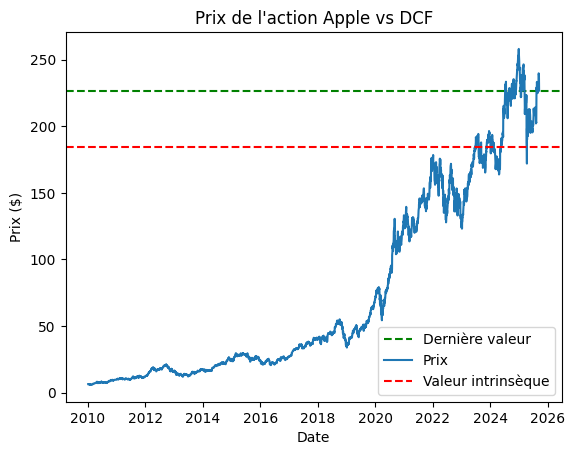

In [ ]:
import matplotlib.pyplot as plt

dataframe = yf.download('AAPL', start='2010-01-01', end='2025-09-11')['Close']
last_price = dataframe.iloc[-1].item()

plt.axhline(last_price, color='g', label='Dernière valeur', linestyle='--')
plt.plot(dataframe, label='Prix')
plt.axhline(value, color='r', label='Valeur intrinsèque', linestyle='--')

plt.title("Prix de l'action Apple vs DCF")
plt.xlabel("Date")
plt.ylabel("Prix ($)")
plt.legend()
plt.show()

In [ ]:
print('#-----------------Intrinsic Value-------------#')
print('P =' , round(value, 2))
print('#--------------------Current Price------------#')
print('C =', round(last_price, 2))
print('#-----------------Recommandation--------------#')

margin = 0.05

if value*(1+margin) > last_price:
  print(round(value,2), '/', 'with margin : ', round(value*(1+margin),2), '/', round(last_price,2))
    print('Buy')
else:
  print(round(value,2), '/', 'with margin : ', round(value*(1+margin),2), '/', round(last_price,2))
    print('Sell')

#-----------------Intrinsic Value-------------#
P = 184.72
#--------------------Current Price------------#
C = 226.79
#-----------------Recommandation--------------#
Sell
184.72 / with margin :  193.95 / 226.79


In [ ]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup

def get_sector_growth_estimate(sector_name):
    """
    Tente de récupérer une estimation de croissance pour le secteur donné.
    Recherchera sur SimplyWallSt, ou autre site si possible.
    """
    # Premier scénario : SimplyWallSt (via leur page secteur) — earnings growth estimé
    # Ex de URL : https://simplywall.st/markets/us/tech
    try:
        url = f"https://simplywall.st/markets/us/{sector_name}"
        resp = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'})
        if resp.status_code == 200:
            soup = BeautifulSoup(resp.text, 'html.parser')
            # On cherche un élément contenant "Expected annual earnings growth" ou similaire
            # Note : ceci est très spécifique au markup du site, donc peut nécessiter adaptation
            elt = soup.find(text=lambda t: t and 'earnings forecast' in t.lower())
            if elt:
                # Extraire le pourcentage
                import re
                m = re.search(r'(\d+\.\d+|\d+)\s*%', elt)
                if m:
                    return float(m.group(1)) / 100  # renvoyer en décimal
    except Exception as e:
        print("Erreur SimplyWallSt scraping:", e)

    # Deuxième scénario : utiliser historique secteur via Damodaran (préchargé localement ou téléchargé)
    # => ici on peut avoir un dictionnaire hardcodé ou un CSV des CAGR secteur
    sector_cagr = {
        'technology': 0.15,   # ex : 15%
        'software': 0.20,
        'semiconductor': 0.18,
        # etc.
    }
    return sector_cagr.get(sector_name.lower(), 0.05)  # fallback 5%

def DCF_with_auto_terminal(fcf, wacc, net_debt, num_shares_outstanding, terminal_growth_rate=None, sector_name=None):
    if terminal_growth_rate is None and sector_name is not None:
        terminal_growth_rate = get_sector_growth_estimate(sector_name)
        print(f"Terminal growth rate auto pour secteur {sector_name} : {terminal_growth_rate:.2%}")
    elif terminal_growth_rate is None:
        terminal_growth_rate = 0.03  # valeur de backup si rien

    # suite de ton DCF comme avant…
    # ...

    # Exemple minimal
    pv_fcf = [fcf[i] / (1 + wacc)**(i+1) for i in range(len(fcf))]
    terminal_value = (fcf[-1] * (1 + terminal_growth_rate)) / (wacc - terminal_growth_rate)
    pv_terminal_value = terminal_value / (1 + wacc)**len(fcf)
    enterprise_value = sum(pv_fcf) + pv_terminal_value
    equity_value = enterprise_value - net_debt
    intrinsic_price = equity_value / num_shares_outstanding
    return intrinsic_price

# Exemple d'utilisation
price = DCF_with_auto_terminal(
    fcf = future_fcf,
    wacc = wacc_value,
    net_debt = net_debt,
    num_shares_outstanding = shares_outstanding,
    terminal_growth_rate = None,
    sector_name = "technology"
)
print("Intrinsic avec terminal growth auto:", price)


Terminal growth rate auto pour secteur technology : 15.00%
Intrinsic avec terminal growth auto: -560.5801225654154


In [ ]:
print("Future FCF projections:", future_fcf)
print("WACC used:", wacc_value)
print("Net Debt:", net_debt)
print("Shares Outstanding:", shares_outstanding)


Future FCF projections: [np.float64(140396734108.54883), np.float64(153278400329.12405), np.float64(167341983819.15665), np.float64(182695927726.2893), np.float64(199458625062.31723)]
WACC used: 0.13625960637520385
Net Debt: 76686000000.0
Shares Outstanding: 14840399872


In [ ]:
cost_of_equity = calculate_cost_of_equity(ticker)
print(cost_of_equity)

/tmp/ipython-input-1121246765.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('^GSPC', start=delay, end=today_dt)
[*********************100%***********************]  1 of 1 completed

0.13893546664866815



/tmp/ipython-input-1121246765.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  market_risk_premium = float(rm - risk_free_rate)


In [ ]:
import datetime as dt
import yfinance as yf
import numpy as np

years = 10
# Dates
today_dt = dt.datetime.today()
delay = today_dt - dt.timedelta(days=365*years)

 # Télécharger le S&P500 (^GSPC)
data = yf.download('^GSPC', start=delay, end=today_dt)

    # Rendement annualisé géométrique (CAGR)
rm = (data["Close"].iloc[-1] / data["Close"].iloc[0]) ** (1/years) - 1

print(rm)

/tmp/ipython-input-1034898545.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('^GSPC', start=delay, end=today_dt)
[*********************100%***********************]  1 of 1 completed

Ticker
^GSPC    0.129203
dtype: float64


## Ratios Financiers

- Marge brute
- Marge opérationnelle
- Marge Nette
- Return on Equity
- Effet de levier
- Ratio courant
- F
- PER
- Price to Book
- Price to Sales
- EV
- Chiffre de Graham

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

plt.rcParams.update({'figure.max_open_warning': 0})

def safe_div(a, b):
    try:
        return a / b
    except Exception:
        return np.nan

def fetch_financials(ticker_symbol):
    t = yf.Ticker(ticker_symbol)
    # yearly financials are columns -> transpose for timeseries by date
    fin = t.financials.transpose() if hasattr(t, "financials") else pd.DataFrame()
    bal = t.balance_sheet.transpose() if hasattr(t, "balance_sheet") else pd.DataFrame()
    cf  = t.cashflow.transpose() if hasattr(t, "cashflow") else pd.DataFrame()
    info = t.info if hasattr(t, "info") else {}
    return fin, bal, cf, info

def compute_ratios_for_ticker(ticker_symbol):
    fin, bal, cf, info = fetch_financials(ticker_symbol)

    # unify indexes as datetime if possible
    def to_dt_index(df):
        if df is None or df.empty:
            return df
        df = df.copy()
        try:
            df.index = pd.to_datetime(df.index)
        except Exception:
            pass
        return df

    fin = to_dt_index(fin)
    bal = to_dt_index(bal)
    cf  = to_dt_index(cf)

    # Build DataFrame with periods present in financials or balance sheet
    # We'll take the union of dates from fin/bal/cf
    dates = []
    for d in [fin, bal, cf]:
        if d is not None and not d.empty:
            dates.extend(list(d.index))
    dates = sorted(list(dict.fromkeys(dates)))  # unique preserve order

    # prepare empty dataframe
    ratios = pd.DataFrame(index=dates, columns=[
        'GrossMargin', 'OperatingMargin', 'NetMargin',
        'ROE', 'DebtToEquity', 'CurrentRatio',
        'PER', 'PriceToBook', 'PriceToSales',
        'EV', 'GrahamNumber', 'PiotroskiF'
    ], dtype=float)

    # helper to get value safely (some fields have slightly different names)
    def get_from_any(df, date, keys):
        if df is None or df.empty:
            return np.nan
        if date not in df.index:
            return np.nan
        row = df.loc[date]
        for k in keys:
            if k in row.index:
                return pd.to_numeric(row.get(k), errors='coerce')
        return np.nan

    # iterate dates and compute
    for dt in dates:
        # revenues / profits
        revenue = get_from_any(fin, dt, ['TotalRevenue', 'Revenue', 'totalRevenue', 'NetRevenue'])
        gross_profit = get_from_any(fin, dt, ['GrossProfit', 'grossProfit'])
        operating_income = get_from_any(fin, dt, ['OperatingIncome', 'operatingIncome', 'OperatingIncomeLoss'])
        net_income = get_from_any(fin, dt, ['NetIncome', 'NetIncomeCommonStockholders', 'NetIncomeLoss'])
        # balance
        total_equity = get_from_any(bal, dt, ['TotalStockholdersEquity', 'TotalEquity', 'StockholdersEquity'])
        total_current_assets = get_from_any(bal, dt, ['TotalCurrentAssets', 'totalCurrentAssets'])
        total_current_liabilities = get_from_any(bal, dt, ['TotalCurrentLiabilities', 'totalCurrentLiabilities'])
        short_term_debt = get_from_any(bal, dt, ['ShortTermDebt', 'Short Long Term Debt', 'ShortLongTermDebt'])
        long_term_debt = get_from_any(bal, dt, ['LongTermDebt', 'Long Term Debt'])
        total_debt = np.nan
        # some sources provide 'TotalDebt' in info only
        if not np.isnan(short_term_debt) or not np.isnan(long_term_debt):
            short_term_debt = 0 if np.isnan(short_term_debt) else short_term_debt
            long_term_debt = 0 if np.isnan(long_term_debt) else long_term_debt
            total_debt = short_term_debt + long_term_debt
        else:
            # fallback to 'TotalDebt' column if present
            total_debt = get_from_any(bal, dt, ['TotalDebt'])
            if np.isnan(total_debt):
                # fallback to info (not time series)
                total_debt = pd.to_numeric(info.get('totalDebt', np.nan), errors='coerce')

        cash = get_from_any(bal, dt, ['Cash', 'CashAndShortTermInvestments', 'CashAndCashEquivalentsAtCarryingValue'])
        if np.isnan(cash):
            cash = pd.to_numeric(info.get('cash', np.nan), errors='coerce') or np.nan

        market_cap = pd.to_numeric(info.get('marketCap', np.nan), errors='coerce')
        price = pd.to_numeric(info.get('currentPrice', np.nan), errors='coerce') or pd.to_numeric(info.get('previousClose', np.nan), errors='coerce')

        shares_out = pd.to_numeric(info.get('sharesOutstanding', np.nan), errors='coerce')
        eps_ttm = pd.to_numeric(info.get('trailingEps', np.nan), errors='coerce')
        book_value_per_share = pd.to_numeric(info.get('bookValue', np.nan), errors='coerce')
        price_to_book_info = pd.to_numeric(info.get('priceToBook', np.nan), errors='coerce')

        # Ratios calculations (with safe_div)
        ratios.loc[dt, 'GrossMargin'] = safe_div(gross_profit, revenue)
        ratios.loc[dt, 'OperatingMargin'] = safe_div(operating_income, revenue)
        ratios.loc[dt, 'NetMargin'] = safe_div(net_income, revenue)
        ratios.loc[dt, 'ROE'] = safe_div(net_income, total_equity)
        ratios.loc[dt, 'DebtToEquity'] = safe_div(total_debt, total_equity)
        ratios.loc[dt, 'CurrentRatio'] = safe_div(total_current_assets, total_current_liabilities)

        # PER: use price / EPS TTM if available, else compute EPS from net_income / shares_out (annualized)
        per = np.nan
        if not np.isnan(price) and not np.isnan(eps_ttm) and eps_ttm != 0:
            per = safe_div(price, eps_ttm)
        else:
            # attempt compute EPS from net income (if per-period net_income corresponds to annual)
            if not np.isnan(net_income) and not np.isnan(shares_out) and shares_out != 0:
                eps = net_income / shares_out
                per = safe_div(price, eps)
        ratios.loc[dt, 'PER'] = per

        # Price to Book
        pb = np.nan
        if not np.isnan(price_to_book_info):
            pb = price_to_book_info
        else:
            if not np.isnan(market_cap) and not np.isnan(total_equity) and total_equity != 0:
                pb = safe_div(market_cap, total_equity)
            elif not np.isnan(price) and not np.isnan(book_value_per_share) and book_value_per_share != 0:
                pb = safe_div(price, book_value_per_share)
        ratios.loc[dt, 'PriceToBook'] = pb

        # Price to Sales
        p_to_s = np.nan
        if not np.isnan(market_cap) and not np.isnan(revenue) and revenue != 0:
            p_to_s = safe_div(market_cap, revenue)
        ratios.loc[dt, 'PriceToSales'] = p_to_s

        # EV = Market Cap + Total Debt - Cash
        ev = np.nan
        if not np.isnan(market_cap):
            td = 0 if np.isnan(total_debt) else total_debt
            csh = 0 if np.isnan(cash) else cash
            ev = market_cap + td - csh
        ratios.loc[dt, 'EV'] = ev

        # Graham Number = sqrt(22.5 * EPS * BVPS)
        # EPS use EPS TTM if present otherwise eps computed above
        eps_for_graham = eps_ttm if not np.isnan(eps_ttm) else (net_income / shares_out if not np.isnan(net_income) and not np.isnan(shares_out) and shares_out!=0 else np.nan)
        bvps = book_value_per_share if not np.isnan(book_value_per_share) else (safe_div(total_equity, shares_out) if not np.isnan(total_equity) and not np.isnan(shares_out) and shares_out!=0 else np.nan)
        if not np.isnan(eps_for_graham) and not np.isnan(bvps) and eps_for_graham>0 and bvps>0:
            ratios.loc[dt, 'GrahamNumber'] = sqrt(22.5 * eps_for_graham * bvps)
        else:
            ratios.loc[dt, 'GrahamNumber'] = np.nan

        # Piotroski F-score (need several signals comparing current vs previous year)
        # We compute F for dates that have a previous available date
        ratios.loc[dt, 'PiotroskiF'] = np.nan  # fill later in a second pass

    # Second pass: compute Piotroski F for periods where previous period exists
    for i in range(1, len(ratios.index)):
        cur = ratios.index[i]
        prev = ratios.index[i-1]
        # fetch necessary raw values from fin/bal/cf for both periods
        def val(df, date, keys):
            return get_from_any(df, date, keys)
        # profitability: net income > 0
        ni_cur = get_from_any(fin, cur, ['NetIncome', 'NetIncomeCommonStockholders', 'NetIncomeLoss'])
        ni_prev = get_from_any(fin, prev, ['NetIncome', 'NetIncomeCommonStockholders', 'NetIncomeLoss'])
        fscore = 0
        # 1) Positive ROA: net income / total assets > 0 (approx using net income)
        total_assets_cur = get_from_any(bal, cur, ['TotalAssets'])
        roa_cur = safe_div(ni_cur, total_assets_cur)
        if not np.isnan(roa_cur) and roa_cur > 0:
            fscore += 1
        # 2) Positive operating cash flow
        ocf_cur = get_from_any(cf, cur, ['TotalCashFromOperatingActivities', 'OperatingCashFlow', 'NetCashProvidedByOperatingActivities'])
        if not np.isnan(ocf_cur) and ocf_cur > 0:
            fscore += 1
        # 3) Higher ROA than previous year
        total_assets_prev = get_from_any(bal, prev, ['TotalAssets'])
        roa_prev = safe_div(ni_prev, total_assets_prev)
        if not np.isnan(roa_cur) and not np.isnan(roa_prev) and roa_cur > roa_prev:
            fscore += 1
        # 4) Cash flow > net income
        if not np.isnan(ocf_cur) and not np.isnan(ni_cur) and ocf_cur > ni_cur:
            fscore += 1
        # 5) Lower leverage than previous year (decrease in long-term debt / total debt or total debt/total assets)
        td_cur = get_from_any(bal, cur, ['TotalDebt']) or (get_from_any(bal, cur, ['ShortTermDebt']) + get_from_any(bal, cur, ['LongTermDebt']))
        td_prev = get_from_any(bal, prev, ['TotalDebt']) or (get_from_any(bal, prev, ['ShortTermDebt']) + get_from_any(bal, prev, ['LongTermDebt']))
        ta_cur = total_assets_cur
        ta_prev = total_assets_prev
        lev_cur = safe_div(td_cur, ta_cur)
        lev_prev = safe_div(td_prev, ta_prev)
        if not np.isnan(lev_cur) and not np.isnan(lev_prev) and lev_cur < lev_prev:
            fscore += 1
        # 6) Higher current ratio than previous year
        cur_curr = safe_div(get_from_any(bal, cur, ['TotalCurrentAssets']), get_from_any(bal, cur, ['TotalCurrentLiabilities']))
        cur_prev = safe_div(get_from_any(bal, prev, ['TotalCurrentAssets']), get_from_any(bal, prev, ['TotalCurrentLiabilities']))
        if not np.isnan(cur_curr) and not np.isnan(cur_prev) and cur_curr > cur_prev:
            fscore += 1
        # 7) No new shares issued (compare shares outstanding)
        so_cur = pd.to_numeric(info.get('sharesOutstanding', np.nan))
        # sharesOutstanding not time-series in yfinance - skip or approximate by comparing book value per share changes; we'll skip this test if not available
        # For robustness, try to use 'CommonStockSharesOutstanding' in balance sheet
        so_cur_bs = get_from_any(bal, cur, ['CommonStockSharesOutstanding', 'SharesOutstanding'])
        so_prev_bs = get_from_any(bal, prev, ['CommonStockSharesOutstanding', 'SharesOutstanding'])
        if not np.isnan(so_cur_bs) and not np.isnan(so_prev_bs) and so_cur_bs <= so_prev_bs:
            fscore += 1
        # 8) Higher gross margin than previous year
        gp_cur = get_from_any(fin, cur, ['GrossProfit'])
        gp_prev = get_from_any(fin, prev, ['GrossProfit'])
        rev_cur = get_from_any(fin, cur, ['TotalRevenue', 'Revenue'])
        rev_prev = get_from_any(fin, prev, ['TotalRevenue', 'Revenue'])
        gm_cur = safe_div(gp_cur, rev_cur)
        gm_prev = safe_div(gp_prev, rev_prev)
        if not np.isnan(gm_cur) and not np.isnan(gm_prev) and gm_cur > gm_prev:
            fscore += 1
        # 9) Higher asset turnover than previous year (revenue / total assets)
        at_cur = safe_div(rev_cur, ta_cur)
        at_prev = safe_div(rev_prev, ta_prev)
        if not np.isnan(at_cur) and not np.isnan(at_prev) and at_cur > at_prev:
            fscore += 1

        ratios.loc[cur, 'PiotroskiF'] = fscore

    # clean index name and sort
    ratios = ratios.sort_index()
    return ratios, info

def plot_ratios(ratios, title_prefix=''):
    # plot selected ratios over time
    plt.figure(figsize=(12, 8))
    # choose subset for multi-line comparison: margins and ROE
    sub = ratios[['GrossMargin', 'OperatingMargin', 'NetMargin', 'ROE']].astype(float)
    sub.plot(marker='o')
    plt.title(f'{title_prefix} Marges & ROE dans le temps')
    plt.ylabel('Ratio')
    plt.grid(True)
    plt.show()

    # Leverage, Current Ratio, Piotroski
    plt.figure(figsize=(10,6))
    sub2 = ratios[['DebtToEquity', 'CurrentRatio']].astype(float)
    sub2.plot(marker='o')
    plt.title(f'{title_prefix} Levier & Ratio courant')
    plt.grid(True)
    plt.show()

    # Valuation metrics
    plt.figure(figsize=(10,6))
    sub3 = ratios[['PER', 'PriceToBook', 'PriceToSales', 'EV']].astype(float)
    sub3.plot(marker='o', secondary_y=['EV'])
    plt.title(f'{title_prefix} Metrics de valorisation')
    plt.grid(True)
    plt.show()

    # Piotroski & Graham
    plt.figure(figsize=(10,5))
    ratios['PiotroskiF'].plot(kind='bar')
    plt.title(f'{title_prefix} Piotroski F-score')
    plt.ylabel('F (0-9)')
    plt.show()

    plt.figure(figsize=(8,5))
    ratios['GrahamNumber'].plot(marker='o')
    plt.title(f'{title_prefix} Graham Number')
    plt.grid(True)
    plt.show()

Ticker: AAPL, Sector: Technology, Industry: Consumer Electronics


,GrossMargin,OperatingMargin,NetMargin,ROE,DebtToEquity,CurrentRatio,PER,PriceToBook,PriceToSales,EV,GrahamNumber,PiotroskiF
2020-09-30,NaN,NaN,NaN,NaN,NaN,NaN,34.666667,51.636196,NaN,3.497182e+12,25.651579,NaN
2021-09-30,NaN,NaN,NaN,NaN,NaN,NaN,34.666667,51.636196,NaN,3.504590e+12,25.651579,0.0
2022-09-30,NaN,NaN,NaN,NaN,NaN,NaN,34.666667,51.636196,NaN,3.494443e+12,25.651579,0.0
2023-09-30,NaN,NaN,NaN,NaN,NaN,NaN,34.666667,51.636196,NaN,3.490765e+12,25.651579,0.0
2024-09-30,NaN,NaN,NaN,NaN,NaN,NaN,34.666667,51.636196,NaN,3.481234e+12,25.651579,0.0


<Figure size 1200x800 with 0 Axes>

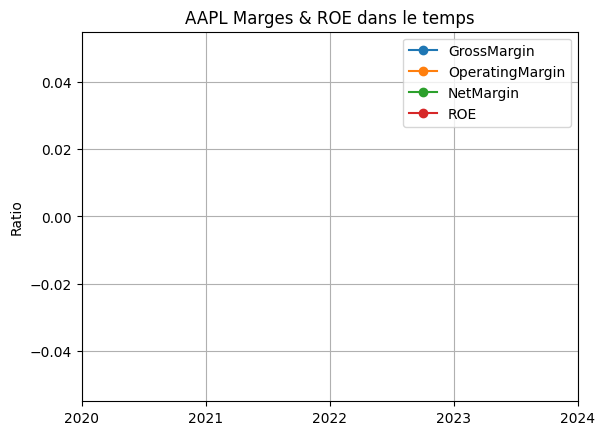

<Figure size 1000x600 with 0 Axes>

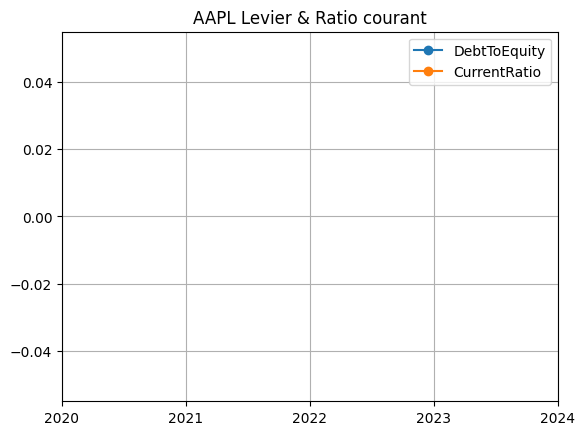

<Figure size 1000x600 with 0 Axes>

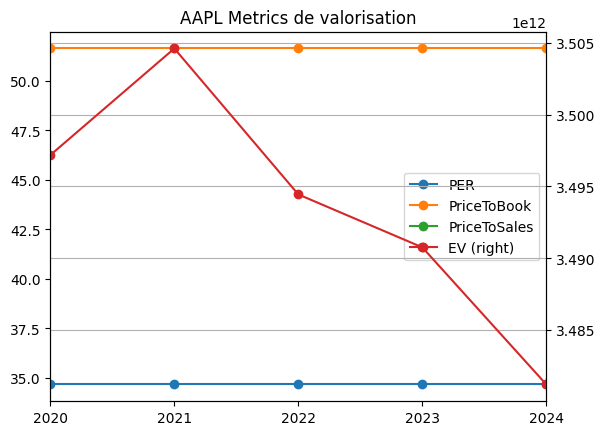

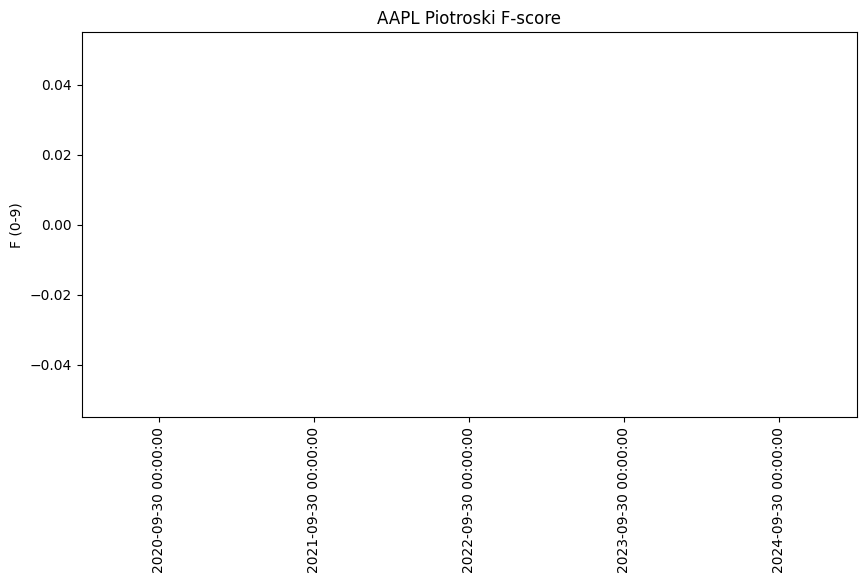

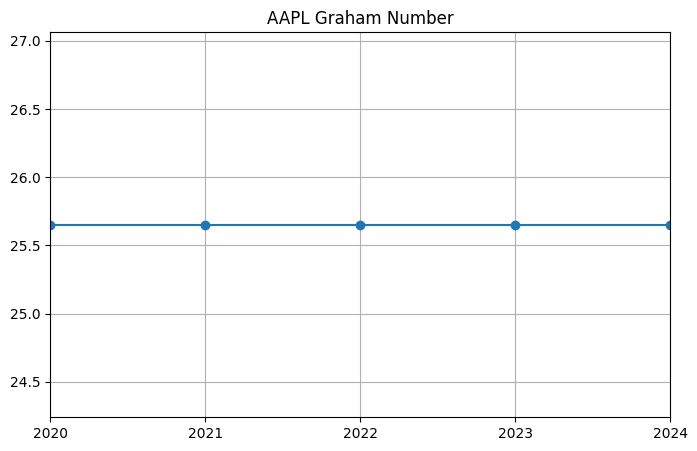

Aucun peer fourni : pass de la comparaison.


In [ ]:
# usage example
target = "AAPL"
peers = []  # si tu veux comparer, mets une liste comme ["MSFT","GOOGL","AMZN"]

ratios_target, info_target = compute_ratios_for_ticker(target)
print(f"Ticker: {target}, Sector: {info_target.get('sector', 'N/A')}, Industry: {info_target.get('industry','N/A')}")
display(ratios_target)  # si dans notebook ; sinon print(ratios_target.tail())

plot_ratios(ratios_target, title_prefix=target)

# comparaison avec peers si fournis
if peers:
    # compute for each peer and plot a comparison for a selected ratio (ex: ROE, PER)
    comp = {}
    for p in peers:
        r, info = compute_ratios_for_ticker(p)
        # take last available value for comparability
        comp[p] = {
            'ROE': r['ROE'].dropna().iloc[-1] if r['ROE'].dropna().size>0 else np.nan,
            'PER': r['PER'].dropna().iloc[-1] if r['PER'].dropna().size>0 else np.nan,
            'PriceToBook': r['PriceToBook'].dropna().iloc[-1] if r['PriceToBook'].dropna().size>0 else np.nan,
            'PiotroskiF': r['PiotroskiF'].dropna().iloc[-1] if r['PiotroskiF'].dropna().size>0 else np.nan
        }
    comp_df = pd.DataFrame(comp).T
    print("Comparaison (derniers valeurs disponibles):")
    display(comp_df)
    # Plot bar charts
    comp_df[['ROE','PER','PriceToBook','PiotroskiF']].plot(kind='bar', subplots=True, layout=(2,2), figsize=(12,8), legend=False)
    plt.suptitle(f'Comparaison: {target} vs peers')
    plt.show()
else:
    print("Aucun peer fourni : pass de la comparaison.")


- Marge brute
- Marge opérationnelle
- Marge Nette
- Return on Equity
- Effet de levier
- Ratio courant
- F
- PER
- Price to Book
- Price to Sales
- EV
- Chiffre de Graham

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from math import sqrt
import datetime

# --- CONFIG ---
DEFAULT_YEARS = 5  # période pour calcul de CAGR pour k et g
SECTOR_ETF_MAP = {
    "Technology": "XLK",
    "Financial Services": "XLF",
    "Financials": "XLF",
    "Energy": "XLE",
    "Health Care": "XLV",
    "Healthcare": "XLV",
    "Consumer Cyclical": "XLY",
    "Consumer Discretionary": "XLY",
    "Consumer Defensive": "XLP",
    "Consumer Staples": "XLP",
    "Industrials": "XLI",
    "Materials": "XLB",
    "Real Estate": "XLRE",
    "Utilities": "XLU",
    "Communication Services": "XLC",
    "Telecommunication Services": "XLC",
}

# --- HELPERS ---
def cagr(start_val, end_val, periods):
    if start_val is None or end_val is None or start_val <= 0:
        return None
    return (end_val / start_val) ** (1.0 / periods) - 1.0

def safe_div(a,b):
    try:
        return None if a is None or b is None or b == 0 else a / b
    except:
        return None

# --- MAIN CALC FUNCTION ---
def compute_ratios_and_gordon(ticker_symbol, years=DEFAULT_YEARS, verbose=True):
    t = yf.Ticker(ticker_symbol)
    info = t.info  # price, marketCap, sector, etc.

    # market data
    price = info.get("regularMarketPrice") or info.get("previousClose")
    market_cap = info.get("marketCap")
    shares_outstanding = info.get("sharesOutstanding")

    # Basic financial statements
    # yfinance returns dataframes; we'll try to pick 'ttm' when possible or latest annual
    try:
        financials = t.financials  # quarterly/annual income statements (columns = periods)
        balance = t.balance_sheet
        cashflow = t.cashflow
        earnings = t.earnings  # yearly earnings dataframe
        # t.quarterly_* also available if you want more granularity
    except Exception as e:
        raise RuntimeError(f"Impossible de récupérer les états via yfinance: {e}")

    # Pick most recent annual columns (if DataFrame columns are datetimes)
    def latest(df):
        if df is None or df.empty:
            return {}
        col = df.columns[0]  # yfinance usually orders with most recent first
        return df[col].to_dict()

    fin = latest(financials)
    bal = latest(balance)
    cf = latest(cashflow)

    # Metrics from income statement / balance sheet
    total_revenue = fin.get("TotalRevenue") or fin.get("Total Revenues") or fin.get("Revenue")
    gross_profit = fin.get("GrossProfit")
    operating_income = fin.get("OperatingIncome") or fin.get("Operating Income")
    net_income = fin.get("NetIncome") or fin.get("Net Income")
    eps_ttm = info.get("trailingEps") or (earnings["Earnings"][-1] if hasattr(earnings, 'shape') else None)

    total_assets = bal.get("TotalAssets")
    total_liab = bal.get("TotalLiab") or bal.get("Total Liab")
    total_equity = bal.get("TotalStockholderEquity") or bal.get("Stockholders Equity")
    current_assets = bal.get("TotalCurrentAssets") or bal.get("Current Assets")
    current_liab = bal.get("TotalCurrentLiabilities") or bal.get("Current Liabilities")
    cash_and_equiv = bal.get("CashAndCashEquivalentsAtCarryingValue") or bal.get("Cash") or cf.get("Cash")
    short_term_invest = bal.get("ShortTermInvestments") or 0

    total_debt = bal.get("ShortLongTermDebt") or bal.get("TotalDebt") or bal.get("LongTermDebt") or 0
    # Some companies report debt in different fields; try sum long and short
    if total_debt is None:
        total_debt = (bal.get("ShortLongTermDebt") or 0) + (bal.get("LongTermDebt") or 0)

    # Basic ratios
    gross_margin = safe_div(gross_profit, total_revenue)
    operating_margin = safe_div(operating_income, total_revenue)
    net_margin = safe_div(net_income, total_revenue)
    roe = safe_div(net_income, total_equity)
    leverage = safe_div(total_assets, total_equity)
    current_ratio = safe_div(current_assets, current_liab)

    # PER
    per = None
    if eps_ttm and price:
        per = safe_div(price, eps_ttm)

    # Price to Book and Price to Sales (using market cap)
    pb = safe_div(market_cap, total_equity) if market_cap and total_equity else None
    ps = safe_div(market_cap, total_revenue) if market_cap and total_revenue else None

    # Enterprise Value
    ev = None
    if market_cap is not None:
        ev = market_cap + (total_debt or 0) - (cash_and_equiv or 0) - (short_term_invest or 0)

    # Graham number
    book_value_per_share = None
    if total_equity and shares_outstanding:
        book_value_per_share = total_equity / shares_outstanding
    graham_number = None
    if eps_ttm and book_value_per_share and eps_ttm > 0 and book_value_per_share > 0:
        graham_number = sqrt(22.5 * eps_ttm * book_value_per_share)

    # Piotroski F-score (F)
    # We'll compute using last two years of financials if available
    def piotroski_score(ticker):
        # uses fundamentals: profitability, leverage/liquidity/turnover, operating efficiency
        score = 0
        try:
            # Get annual financials (columns = periods)
            inc = t.financials
            bal_s = t.balance_sheet
            cf_s = t.cashflow
            if inc is None or bal_s is None:
                return None
            # yfinance columns: most recent first
            if inc.shape[1] < 2:
                return None
            cur = inc.iloc[:,0]
            prev = inc.iloc[:,1]
            # Profitability
            if cur.get("NetIncome") and prev.get("NetIncome") and cur["NetIncome"] > 0:
                score += 1
            if cur.get("NetIncome") and prev.get("NetIncome") and cur["NetIncome"] > prev["NetIncome"]:
                score += 1
            # ROA: net income / total assets (use current assets)
            cur_bal = bal_s.iloc[:,0]
            prev_bal = bal_s.iloc[:,1] if bal_s.shape[1] > 1 else None
            cur_roa = safe_div(cur.get("NetIncome"), cur_bal.get("TotalAssets")) if cur_bal is not None else None
            prev_roa = safe_div(prev.get("NetIncome"), prev_bal.get("TotalAssets")) if prev_bal is not None else None
            if cur_roa is not None and cur_roa > 0:
                score += 1
            if cur_roa is not None and prev_roa is not None and cur_roa > prev_roa:
                score += 1
            # Leverage, liquidity and source of funds
            # Leverage decreased? (total long term debt current vs prev)
            cur_ld = cur_bal.get("LongTermDebt") or cur_bal.get("Long Term Debt") or 0
            prev_ld = prev_bal.get("LongTermDebt") or 0 if prev_bal is not None else None
            if prev_ld is not None and cur_ld < prev_ld:
                score += 1
            # Current ratio improved?
            cur_cr = safe_div(cur_bal.get("TotalCurrentAssets"), cur_bal.get("TotalCurrentLiabilities"))
            prev_cr = safe_div(prev_bal.get("TotalCurrentAssets"), prev_bal.get("TotalCurrentLiabilities")) if prev_bal is not None else None
            if prev_cr is not None and cur_cr is not None and cur_cr > prev_cr:
                score += 1
            # No new shares issued? compare shares outstanding if available
            # yfinance doesn't give easy shares by year; skip if not available
            # Operating efficiency: gross margin improvement & asset turnover improvement
            cur_gm = safe_div(cur.get("GrossProfit"), cur.get("TotalRevenue"))
            prev_gm = safe_div(prev.get("GrossProfit"), prev.get("TotalRevenue"))
            if cur_gm is not None and prev_gm is not None and cur_gm > prev_gm:
                score += 1
            # Asset turnover: revenue / total assets
            cur_at = safe_div(cur.get("TotalRevenue"), cur_bal.get("TotalAssets")) if cur_bal is not None else None
            prev_at = safe_div(prev.get("TotalRevenue"), prev_bal.get("TotalAssets")) if prev_bal is not None else None
            if cur_at is not None and prev_at is not None and cur_at > prev_at:
                score += 1
            return score
        except Exception:
            return None

    f_score = piotroski_score(ticker_symbol)

    # --- GORDON-SHAPIRO ---
    # choose sector ETF
    sector = info.get("sector")
    chosen_etf = SECTOR_ETF_MAP.get(sector, None)
    # fallback: use SPY if unknown
    if chosen_etf is None:
        chosen_etf = "SPY"

    etf = yf.Ticker(chosen_etf)
    end = datetime.datetime.now().date()
    start = end.replace(year=end.year - years)

    # get historical prices for ETF and compute CAGR of total returns approximation (close prices used)
    etf_hist = etf.history(start=start, end=end, interval="1d", auto_adjust=True)
    k = None
    try:
        # use adjusted close series
        adj = etf_hist["Close"].dropna()
        if len(adj) > 1:
            start_price = adj.iloc[0]
            end_price = adj.iloc[-1]
            k = cagr(start_price, end_price, years)
    except Exception:
        k = None

    # compute g: EPS CAGR for the company using earnings history (if available)
    g = None
    try:
        earnings_df = t.earnings  # year, earnings
        if earnings_df is not None and earnings_df.shape[0] >= 2:
            # pick earliest available within period and latest
            recent_years = earnings_df.tail(min( max(2, years), earnings_df.shape[0] ))
            if recent_years.shape[0] >= 2:
                start_eps = recent_years.iloc[0]["Earnings"]
                end_eps = recent_years.iloc[-1]["Earnings"]
                g = cagr(start_eps, end_eps, recent_years.shape[0]-1)
    except Exception:
        g = None

    # fallback: revenue CAGR if EPS not possible
    if g is None:
        try:
            inc_hist = t.financials  # columns=periods
            if inc_hist is not None and inc_hist.shape[1] >= 2:
                # use oldest available in the slice vs most recent
                ncols = min(inc_hist.shape[1], years+1)
                cols = inc_hist.columns[:ncols]
                rev_start = inc_hist[cols[-1]].get("TotalRevenue", None)
                rev_end = inc_hist[cols[0]].get("TotalRevenue", None)
                if rev_start and rev_end:
                    g = cagr(rev_start, rev_end, len(cols)-1)
        except Exception:
            g = None

    # compute D1 (expected dividend next year)
    dividend_per_share = info.get("dividendRate")  # annual dividend
    dividend_yield = info.get("dividendYield")
    payout_ratio = None
    if dividend_per_share is None and dividend_yield and price:
        dividend_per_share = dividend_yield * price
    # payout ratio estimate = totalDividends / netIncome (not always available)
    total_div_paid = cf.get("DividendsPaid") if cf else None
    if total_div_paid and net_income:
        payout_ratio = safe_div(abs(total_div_paid), net_income)
    # D1:
    D1 = None
    if dividend_per_share:
        # assume same dividend next year (no growth) and then grow by g for Gordon formula which uses next dividend.
        D1 = dividend_per_share * (1 + (g or 0))
    else:
        # estimate via payout ratio: D = EPS * payout_ratio
        if eps_ttm and payout_ratio:
            D_est = eps_ttm * payout_ratio
            D1 = D_est * (1 + (g or 0))

    gordon_value = None
    gordon_warning = None
    if D1 is not None and k is not None and g is not None:
        if k <= g:
            gordon_warning = f"Impossible: k <= g ({k} <= {g}). Gordon formula would be invalid."
        else:
            gordon_value = D1 / (k - g)

    # Prepare results
    results = {
        "ticker": ticker_symbol,
        "price": price,
        "market_cap": market_cap,
        "gross_margin": gross_margin,
        "operating_margin": operating_margin,
        "net_margin": net_margin,
        "roe": roe,
        "leverage": leverage,
        "current_ratio": current_ratio,
        "piotroski_f": f_score,
        "per": per,
        "price_to_book": pb,
        "price_to_sales": ps,
        "enterprise_value": ev,
        "graham_number": graham_number,
        "book_value_per_share": book_value_per_share,
        "eps_ttm": eps_ttm,
        "sector": sector,
        "sector_etf": chosen_etf,
        "k (etf_cagr)": k,
        "g (eps_or_revenue_cagr)": g,
        "D1_estimated": D1,
        "gordon_value": gordon_value,
        "gordon_warning": gordon_warning
    }

    if verbose:
        for k_, v in results.items():
            print(f"{k_:30}: {v}")
    return results

# --- USAGE EXAMPLE ---
if __name__ == "__main__":
    # change le ticker ici
    ticker = "AAPL"   # ex: "AAPL"
    res = compute_ratios_and_gordon(ticker)
